# ERA5 vs the ARM observations at Utqiaġvik

Recreates the season phase-hour stack for the single ERA5 grid cell holding the
DOE ARM facility, then collapses it to the two categories Genie's observational
figure uses — **liquid containing** (red) and **ice only** (blue) — so the two
can be read side by side.

## What is and is not comparable

**The coloured hours are.** Both figures count hours per season in which a
liquid-containing or ice-only cloud was overhead at Utqiaġvik.

**Her precipitating categories are not separated here.** Genie splits
precipitating cases into lighter shades. This analysis applies no precipitation
filter, so:

| ERA5 category | corresponds to, in her figure |
|---|---|
| liquid containing | red **+** pink (`with liquid` + `with liquid (precip)`) |
| ice only | blue **+** light blue (`ice only` + `ice only (precip)`) |

**Bar heights are not.** Her bars run to the full season because she stacks
clear sky and a hatched *missing / no data* category on top. These bars stop at
the overcast total. Pass `include_clear=True` to add a grey remainder and match
her layout — the annotation still reports the overcast hours either way.

**ERA5 has no missing data.** A season short of hours is scaled up to the
nominal window rather than shown as a gap, so there is no counterpart to her
hatched bars. `--min-season-coverage` guards against that scaling being applied
to a badly incomplete season.

**Sampling differs.** ERA5 is a 0.25° grid-box average sampled hourly; the ARM
instruments see a point, far faster. Occupancy fractions compare; event
durations do not.

## Setup

In [14]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures/genie_comparison")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the data

Set the season window and years to match the observational record you are
comparing against. Genie's figure runs 2015–2025.

In [ ]:
A = lwph.prepare(
    region="barrow",
    years=tuple(range(2014, 2026)),   # season START years, matching Genie's span
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.90,            # IWP/CWP at or above this = ice only

    min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.99,          # overcast only
    lsm_tol=0.01,
    storage="local",
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 107,856 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.99
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001:  99.5%
    2001/2002:  50.3%   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013:  99.5%
    2013/2014:  99.5%
    2014/2015:  99.5%
    2015/2016: 100.0%
    2016/2017:  99.5%
    2017/2018:  93.4%
    2018/2019:  99.5%
    2019/2020: 100.0%
    2020/2021: 

## 1. Three categories — liquid only, mixed phase, ice only

The figure from the per-class notebook, for the ARM cell alone. One grid cell,
so no averaging over cells is involved.

  -> figures/genie_comparison/barrow_season_phase_stack_site_mean2014-2024.png


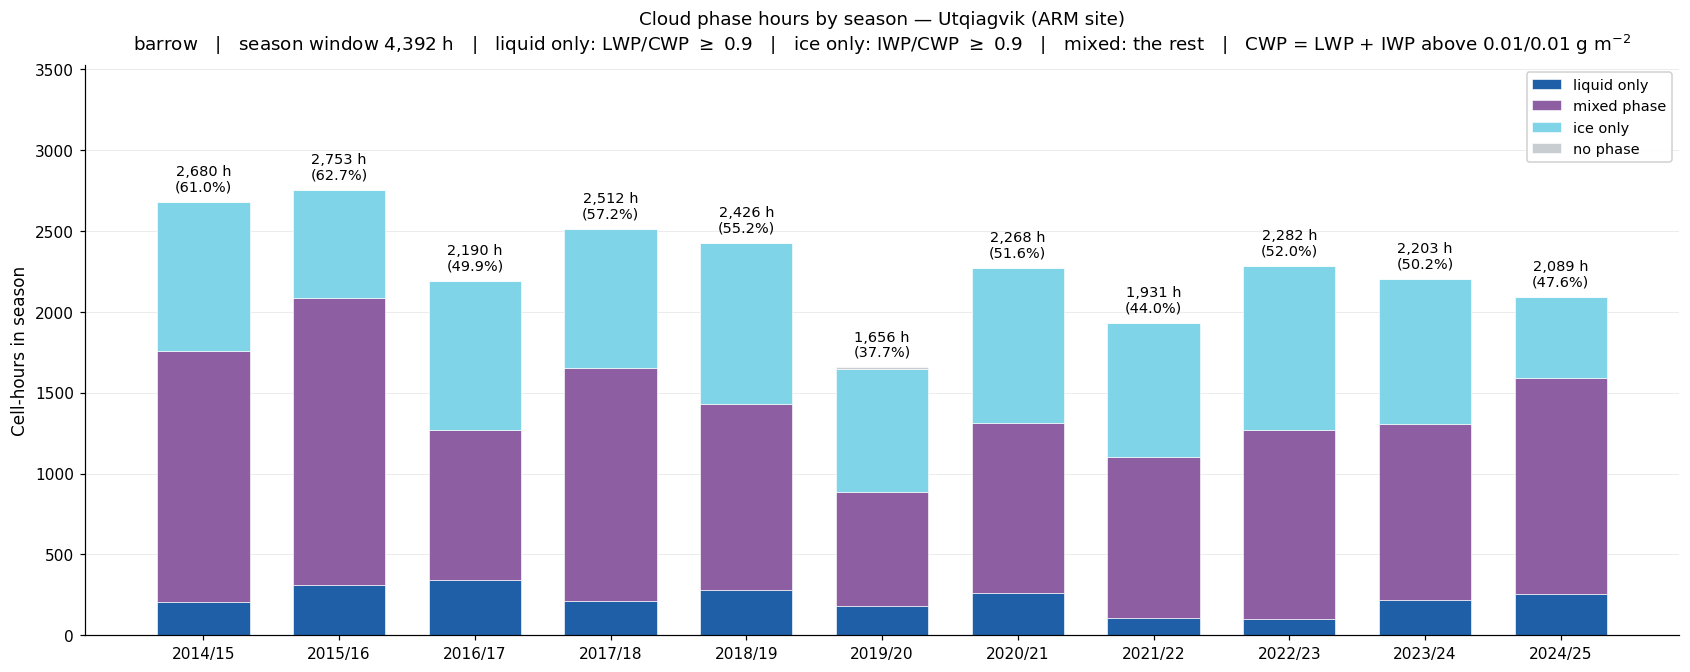

In [16]:
lwph.fig_season_phase_stack_site(A, out_dir=SAVE_DIR);

## 2. Two categories — liquid containing vs ice only

Liquid only and mixed phase are merged into **liquid containing**: both are
scenes an instrument would report as having liquid somewhere in the column. The
small *no phase* residual is folded into ice-only rather than dropped, so the
two still sum to the overcast total — it is overcast time carrying no cloud
water above the minimum paths, which nothing would call liquid.

Colours match Genie's figure exactly.

  -> figures/genie_comparison/barrow_season_phase_binary_site_mean2014-2024.png


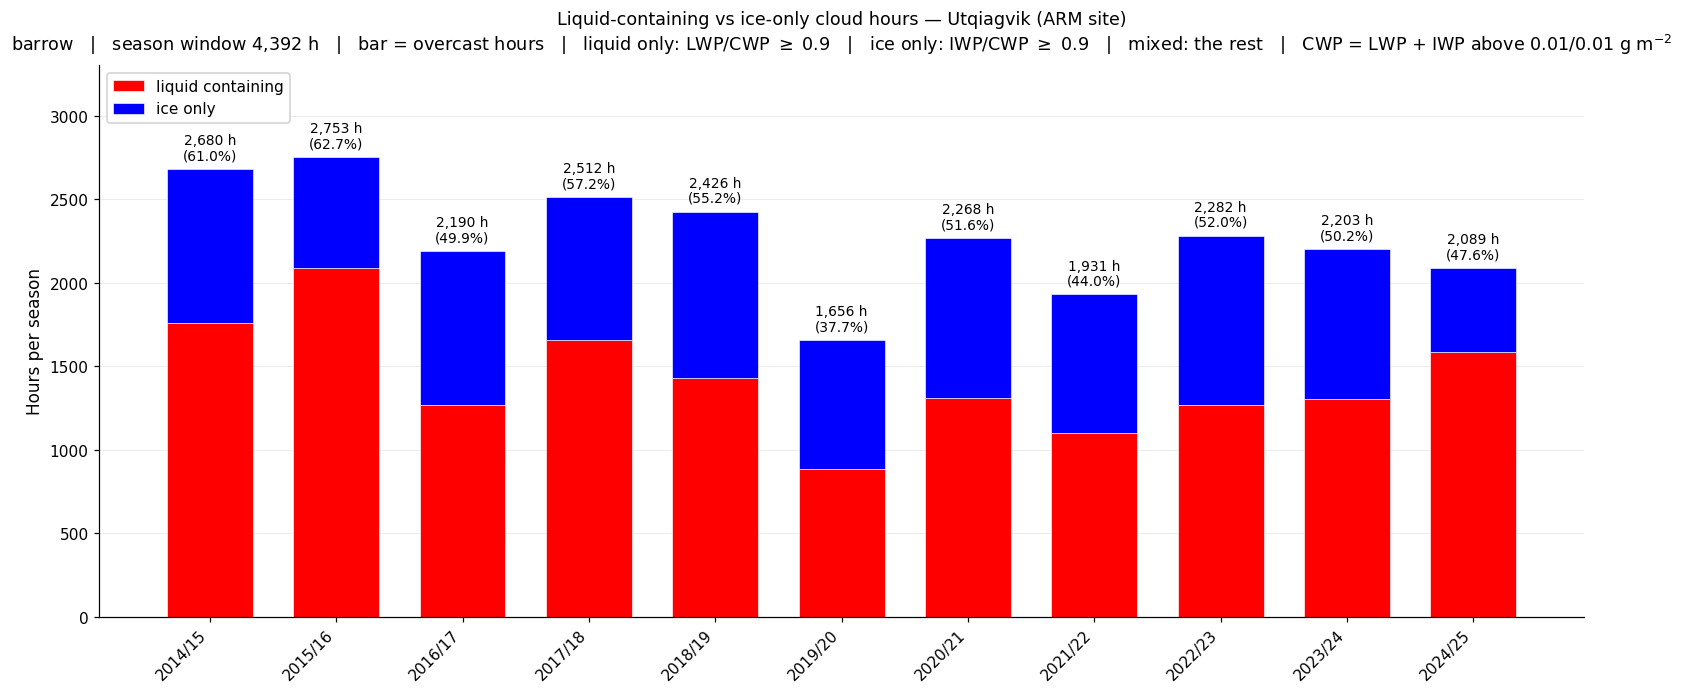

In [17]:
lwph.fig_season_phase_binary(A, out_dir=SAVE_DIR);

### The same, with clear sky stacked on top

Matches her layout, where each bar spans the whole season. The annotation still
gives the overcast hours, not the bar height.

  -> figures/genie_comparison/barrow_season_phase_binary_site_mean2014-2024.png


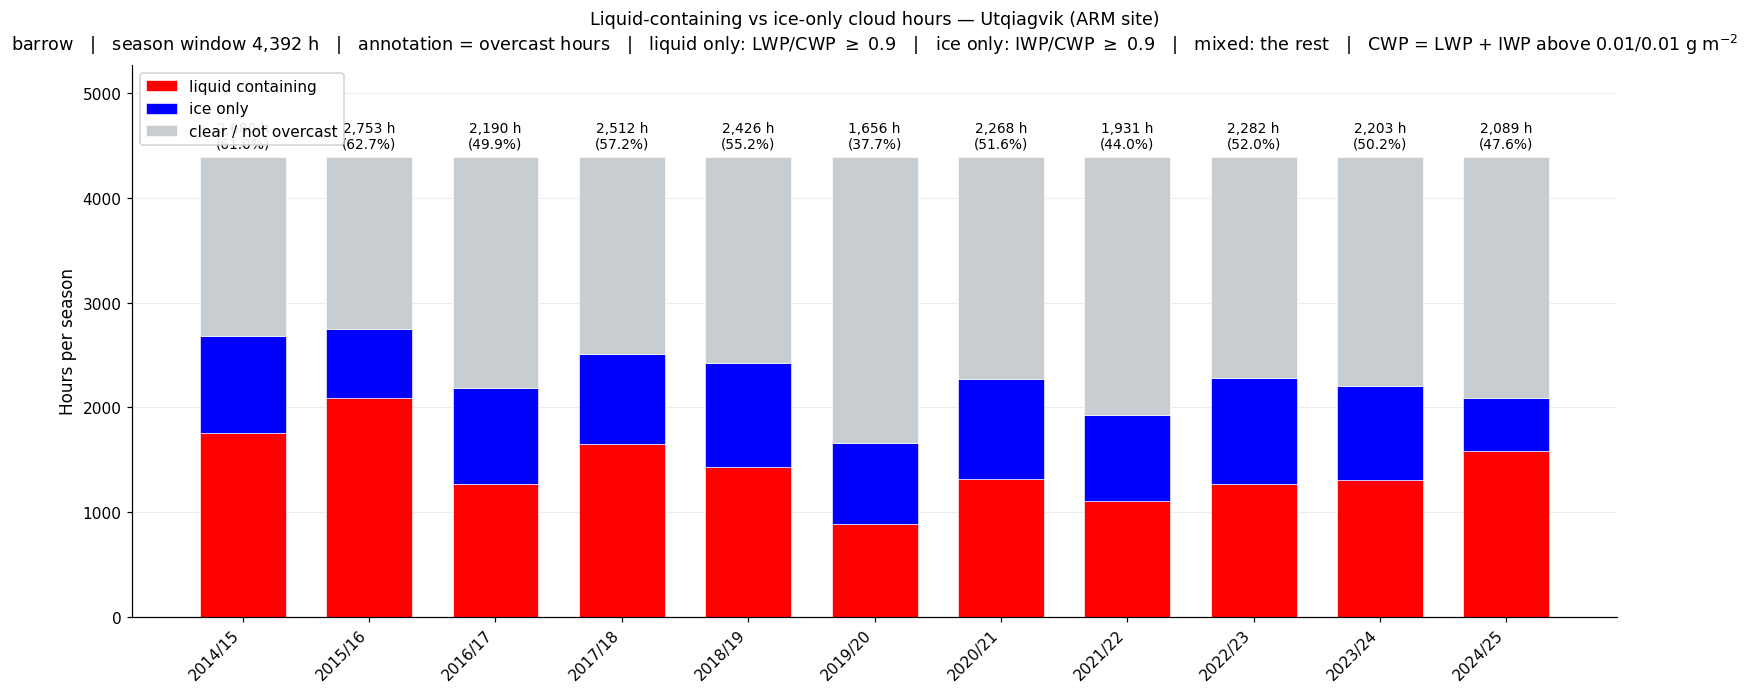

In [18]:
lwph.fig_season_phase_binary(A, include_clear=True, out_dir=SAVE_DIR);

## 3. The numbers, against hers

Her figure's legend gives the record means. The comparison to make is ERA5's
liquid-containing against her red **+** pink, and ERA5's ice-only against her
blue **+** light blue.

In [19]:
import numpy as np

labels, liquid, ice, clear, season_h = lwph.season_phase_binary(A)
code_i, series_label = lwph.resolve_series_code(A.col, "arm_site")
liq, ic = liquid[:, code_i], ice[:, code_i]

print(f"{series_label} | season window {season_h:,.0f} h\n")
print(f"  {'season':<10}{'liquid-cont':>13}{'ice only':>11}{'cloudy':>10}"
      f"{'% season':>10}{'liq share':>11}")
for i, lab in enumerate(labels):
    tot = liq[i] + ic[i]
    print(f"  {lab:<10}{liq[i]:>13,.0f}{ic[i]:>11,.0f}{tot:>10,.0f}"
          f"{100 * tot / season_h:>9.1f}%{100 * liq[i] / tot:>10.1f}%")

print(f"\n  ERA5 mean        liquid-containing {liq.mean():>7,.0f} h"
      f"   ice-only {ic.mean():>7,.0f} h"
      f"   liquid share {100 * liq.mean() / (liq.mean() + ic.mean()):.1f}%")

# Genie's legend values, per season, for the same site.
OBS = {"with liquid": 1474, "with liquid (precip)": 282,
       "ice only": 1071, "ice only (precip)": 255}
obs_liq = OBS["with liquid"] + OBS["with liquid (precip)"]
obs_ice = OBS["ice only"] + OBS["ice only (precip)"]
print(f"  ARM  (obs)       liquid-containing {obs_liq:>7,.0f} h"
      f"   ice-only {obs_ice:>7,.0f} h"
      f"   liquid share {100 * obs_liq / (obs_liq + obs_ice):.1f}%")
print(f"  ERA5 - ARM       {liq.mean() - obs_liq:>+21,.0f} h"
      f"{ic.mean() - obs_ice:>+19,.0f} h")

Utqiagvik (ARM site) | season window 4,392 h

  season      liquid-cont   ice only    cloudy  % season  liq share
  2014/15           1,758        922     2,680     61.0%      65.6%
  2015/16           2,086        667     2,753     62.7%      75.8%
  2016/17           1,270        920     2,190     49.9%      58.0%
  2017/18           1,654        857     2,512     57.2%      65.9%
  2018/19           1,432        994     2,426     55.2%      59.0%
  2019/20             886        770     1,656     37.7%      53.5%
  2020/21           1,311        957     2,268     51.6%      57.8%
  2021/22           1,101        830     1,931     44.0%      57.0%
  2022/23           1,268      1,015     2,282     52.0%      55.6%
  2023/24           1,303        900     2,203     50.2%      59.1%
  2024/25           1,588        502     2,089     47.6%      76.0%

  ERA5 mean        liquid-containing   1,423 h   ice-only     849 h   liquid share 62.7%
  ARM  (obs)       liquid-containing   1,756 h  

## 4. The precipitation filter

### Use `tp`, and no download is needed

The published convention for "ERA5 says it is precipitating" is **0.1 mm hr⁻¹**
([Zhang et al. 2024, *J. Climate*](https://journals.ametsoc.org/view/journals/clim/37/5/JCLI-D-23-0302.1.xml)),
chosen to match a rain gauge's minimum measurable amount. That threshold is
defined on a **rate**, and ERA5 carries the rate directly as `tp` — total
precipitation, accumulated over the hour ending at the validity time, in metres
of water equivalent. So `mm hr⁻¹ = tp × 1000`.

**It is already in the archive.** Checked: present in all 654 single-level
files, finite everywhere, covering every season 2014/15–2025/26 at 93–100% of
the Oct–Mar window. It is also already in all three downloader variable sets
(`core`, `recommended`, `extended`), so future downloads keep it. Nothing to
download and nothing to add.

### Why not the column water paths

`tcrw + tcsw` is a suspended **mass path**, not a rate, so using it means
inferring a rate from a burden — which needs a fall speed and a layer depth
neither of which ERA5 gives you. I calibrated that route against `tp` in your
own data and it tops out around 94% agreement:

| | value |
|---|---|
| median rain+snow path where `tp` = 0.08–0.12 mm hr⁻¹ | 48.8 g m⁻² |
| physical `W = R·H/v`, H = 1 km, rain (v = 4 m/s) | 6.9 g m⁻² |
| same, snow (v = 1 m/s) | 27.8 g m⁻² |
| 5th–95th percentile of the path at `tp` ≥ 0.1 mm hr⁻¹ | **21–599 g m⁻²** |

That last row is the point: the burden corresponding to a given rate spans more
than an order of magnitude, so *no* mass-path cut reproduces the rate cut
cleanly. There is no reason to accept that error when the rate itself is on
disk. `precip_var="path"` remains available for comparison, but `"rate"` is now
the default.

### Why it matters for the observations

Genie separates precipitating cases into their own categories, so the filter is
what makes the two sides mean the same thing:

| ERA5 setting | compared against |
|---|---|
| `no_precip=False` | her red **+** pink, blue **+** light blue |
| `no_precip=True` | her red and blue **alone** |

`fig_era5_vs_obs` reads `A.args.no_precip` and picks the matching observation
columns automatically, so the pairing cannot drift out of sync with the run.

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 107,856 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.99
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001:  99.5%
    2001/2002:  50.3%   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013:  99.5%
    2013/2014:  99.5%
    2014/2015:  99.5%
    2015/2016: 100.0%
    2016/2017:  99.5%
    2017/2018:  93.4%
    2018/2019:  99.5%
    2019/2020: 100.0%
    2020/2021: 

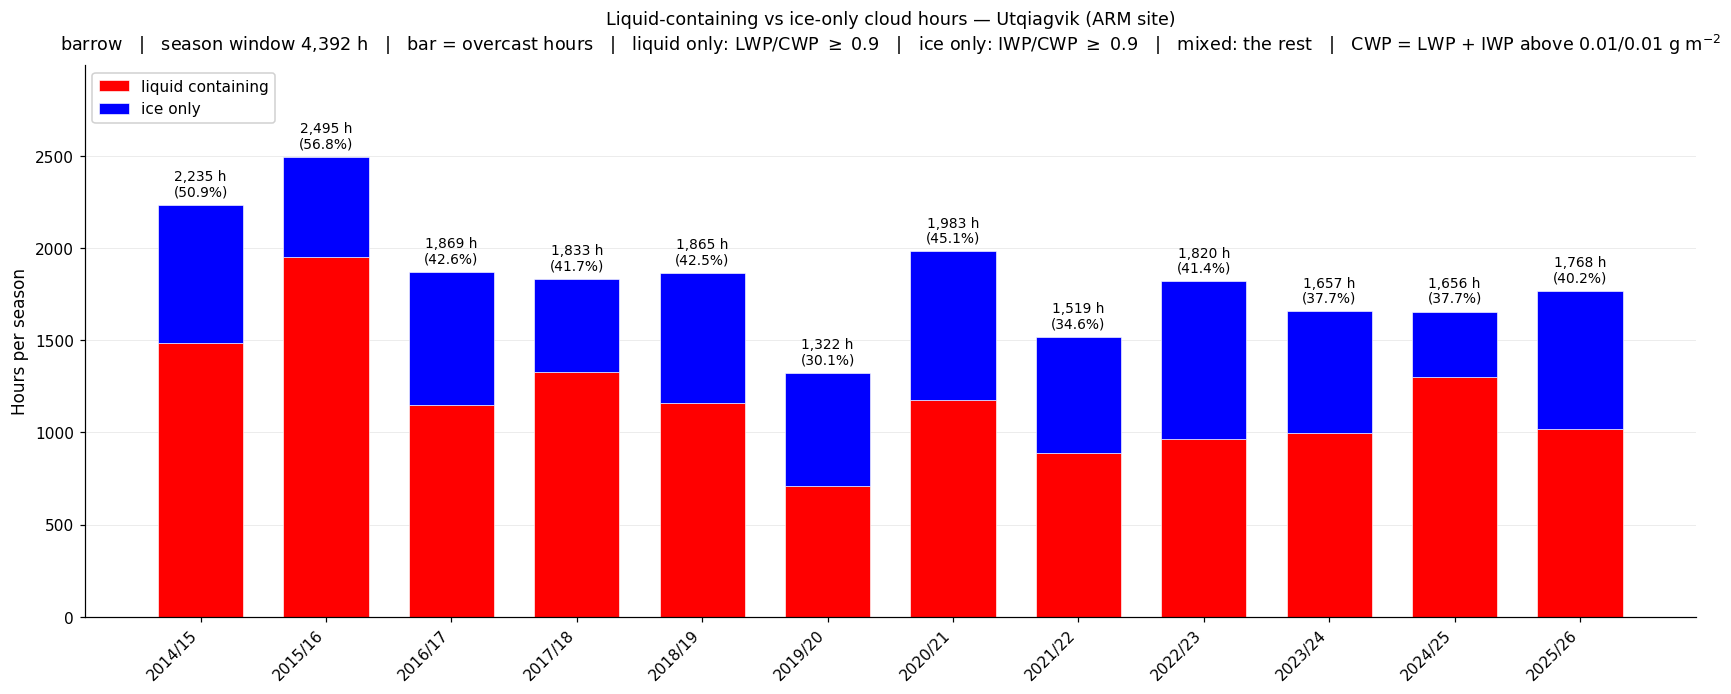

In [ ]:
A_precip = lwph.prepare(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years, matching Genie's span
    season_start=(10, 1), season_end=(3, 31),
    phase_mode="fraction", liquid_fraction_min=0.90, ice_fraction_min=0.90,
    min_lwp=0.01, min_iwp=0.01, min_cloud_fraction=0.99, lsm_tol=0.01,
    storage="local",

    no_precip=True,             # <- the filter
    precip_var="rate",          # tp, the quantity the 0.1 mm/hr convention uses
    precip_rate_max=0.05,        # mm hr-1
)

removed = A_precip.col["precip_removed"]
before = A_precip.col["cloudy_before_precip"]
print(f"precip filter removed {100 * removed / before:.1f}% of cloudy cell-hours")
lwph.fig_season_phase_binary(A_precip, out_dir=SAVE_DIR);

## 5. ERA5 beside the observations, with residuals

### About the observation file

`genie_arm_seasonal_hours.txt` holds the ARM numbers. **Its values were read off
the figure by eye, not supplied as data** — the header says so at length. Expect
±75 h on a thick segment and worse on the thin precipitating ones.

That uncertainty is *comparable to the residuals being plotted*, which is why
the residual panel carries a grey ±150 h band. Treat anything inside it as
consistent with zero until the real numbers replace the file.

The digitisation is anchored on the record means in her legend, which **are**
exact, and `load_observations` checks the columns average to them. Current
agreement: −3 h on `with_liquid`, −11 h on `ice_only`, −57 h on the thin
`liq_precip`.

**Season labelling.** Her figure labels each bar by the year the season *ends* —
her "2015" is the 2014/15 season. The file uses the **start** year to match the
ERA5 side, so every label in it is her label minus one. Her record runs 2014/15
to 2024/25 (11 seasons). Getting this wrong shifts every comparison by a full
season and would not look obviously wrong on the plot.

To replace with real data: overwrite the file keeping the column order and the
start-year convention, then delete the warning block. Nothing else changes.

observation seasons: 2014/15 .. 2024/25  (11 seasons)
  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_mean2014-2024.png


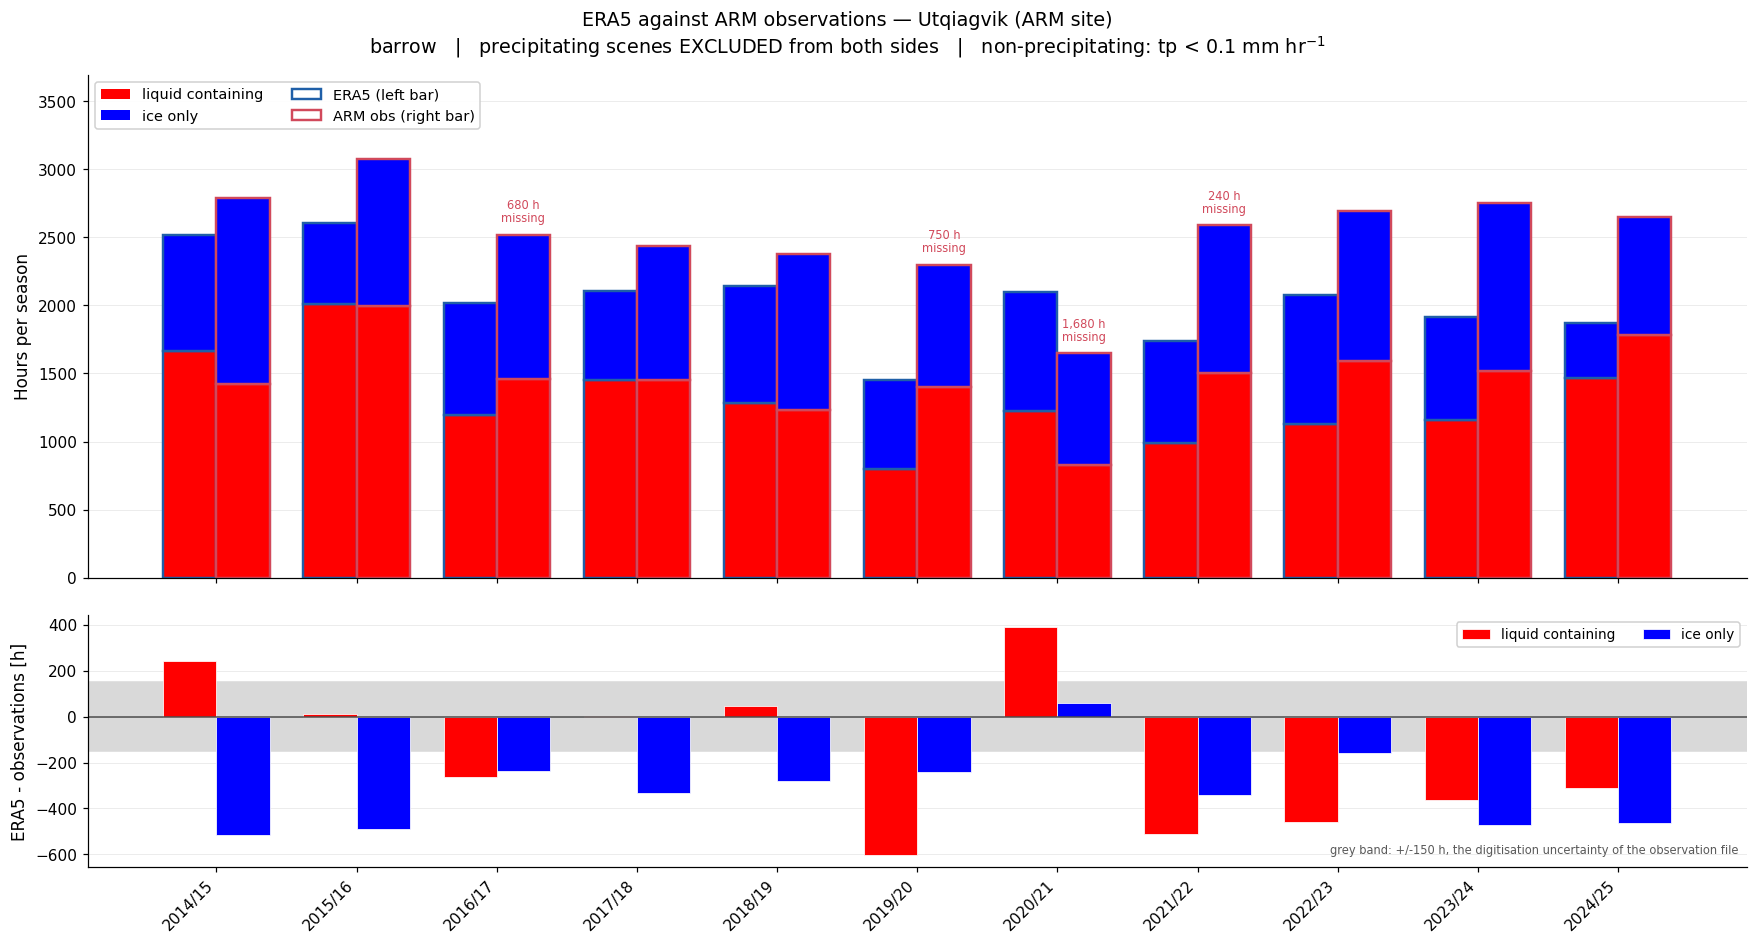

In [21]:
obs = lwph.load_observations()          # validates against the legend means
print(f"observation seasons: {obs['seasons'][0]}/{(obs['seasons'][0]+1)%100:02d}"
      f" .. {obs['seasons'][-1]}/{(obs['seasons'][-1]+1)%100:02d}"
      f"  ({len(obs['seasons'])} seasons)")

# Set USE_PRECIP_FILTER to choose which pairing to plot. The observation
# categories follow automatically.
USE_PRECIP_FILTER = True
A_cmp = A_precip if USE_PRECIP_FILTER else A

lwph.fig_era5_vs_obs(A_cmp, out_dir=SAVE_DIR);

### Both pairings, side by side

Whether the filter helps is an empirical question, so run it both ways.

In [22]:
import numpy as np

for A_i, tag in ((A, "all-sky"), (A_precip, "precip filtered")):
    labels, liq, ice, _, sh = lwph.season_phase_binary(A_i)
    c, _ = lwph.resolve_series_code(A_i.col, "arm_site")
    o_l, o_i = lwph.obs_binary(obs, exclude_precip=A_i.args.no_precip)
    print(f"\n{tag}:")
    print(f"  ERA5  liquid-containing {liq[:, c].mean():>7,.0f} h"
          f"   ice-only {ice[:, c].mean():>7,.0f} h"
          f"   liquid share {100*liq[:, c].mean()/(liq[:, c].mean()+ice[:, c].mean()):.1f}%")
    print(f"  ARM   liquid-containing {o_l.mean():>7,.0f} h"
          f"   ice-only {o_i.mean():>7,.0f} h"
          f"   liquid share {100*o_l.mean()/(o_l.mean()+o_i.mean()):.1f}%")
    print(f"  diff  {liq[:, c].mean()-o_l.mean():>+22,.0f} h"
          f"{ice[:, c].mean()-o_i.mean():>+20,.0f} h")


all-sky:
  ERA5  liquid-containing   1,423 h   ice-only     849 h   liquid share 62.7%
  ARM   liquid-containing   1,695 h   ice-only   1,321 h   liquid share 56.2%
  diff                    -272 h                -473 h

precip filtered:
  ERA5  liquid-containing   1,305 h   ice-only     744 h   liquid share 63.7%
  ARM   liquid-containing   1,471 h   ice-only   1,060 h   liquid share 58.1%
  diff                    -165 h                -316 h


## Reading the comparison

Two questions worth separating when the numbers disagree:

1. **Does ERA5 see cloud as often?** Compare the cloudy totals — ERA5's
   overcast hours against her red + pink + blue + light blue.
2. **Given cloud, does ERA5 get the phase split right?** Compare the liquid
   share, which is insensitive to (1) and is the more physically interesting
   question.

They can fail independently: ERA5 could be too cloudy with the right phase mix,
or correctly cloudy with too little liquid. The `liq share` column above is
built for the second question.

If you want to test sensitivity, `min_lwp` / `min_iwp` and `min_cloud_fraction`
are the levers — each needs a fresh `prepare()`. `liquid_fraction_min` and
`ice_fraction_min` change where the liquid/mixed/ice boundaries fall but not the
liquid-containing vs ice-only split, since that merge is insensitive to the
liquid–mixed boundary.